<center>
<h1>Passenger Traffic Classification at SFO: A 23-Year Machine Learning Analysis</h1>

<h3>Andrew Hashoush, Christopher Guillen, and Dana Neuman</h3>

<h4>April 13th, 2026</h4>
</center>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data/Air_Traffic_Passenger_Statistics.csv")

df.head()

,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at
0,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,31432,2026/03/20 01:00:30 PM,2026/03/22 03:02:50 PM
1,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,31353,2026/03/20 01:00:30 PM,2026/03/22 03:02:50 PM
2,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,2518,2026/03/20 01:00:30 PM,2026/03/22 03:02:50 PM
3,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,1324,2026/03/20 01:00:30 PM,2026/03/22 03:02:50 PM
4,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,1198,2026/03/20 01:00:30 PM,2026/03/22 03:02:50 PM


# Data Preprocessing

In [3]:
# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# convert date
df["activity_period"] = pd.to_datetime(df["activity_period"].astype(str), format="%Y%m")
df = df.dropna(subset=["activity_period"])

df["year"] = df["activity_period"].dt.year
df["month"] = df["activity_period"].dt.month

# sort by time for time split, chronological sort ensures no future data leaks into training data
df = df.sort_values("activity_period")

df.info()

<class 'pandas.DataFrame'>
Index: 39588 entries, 0 to 39587
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   activity_period              39588 non-null  datetime64[us]
 1   activity_period_start_date   39588 non-null  str           
 2   operating_airline            39588 non-null  str           
 3   operating_airline_iata_code  39272 non-null  str           
 4   published_airline            39588 non-null  str           
 5   published_airline_iata_code  39272 non-null  str           
 6   geo_summary                  39588 non-null  str           
 7   geo_region                   39588 non-null  str           
 8   activity_type_code           39588 non-null  str           
 9   price_category_code          39588 non-null  str           
 10  terminal                     39588 non-null  str           
 11  boarding_area                39588 non-null  str         

In [4]:
# checking for dupilcate rows
print("Duplicates:", df.duplicated().sum())
#checking for missing values across columns
print("\nMissing values per column:", df.isnull().sum())

Duplicates: 0

Missing values per column: activity_period                  0
activity_period_start_date       0
operating_airline                0
operating_airline_iata_code    316
published_airline                0
published_airline_iata_code    316
geo_summary                      0
geo_region                       0
activity_type_code               0
price_category_code              0
terminal                         0
boarding_area                    0
passenger_count                  0
data_as_of                       0
data_loaded_at                   0
year                             0
month                            0
dtype: int64


In [5]:
#dropping obvious insignifcant columns or redundant columns
df = df.drop(["operating_airline_iata_code", "published_airline_iata_code", "activity_period_start_date", "data_as_of",
                    "data_loaded_at"], axis=1, errors='ignore')
df.info()

<class 'pandas.DataFrame'>
Index: 39588 entries, 0 to 39587
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   activity_period      39588 non-null  datetime64[us]
 1   operating_airline    39588 non-null  str           
 2   published_airline    39588 non-null  str           
 3   geo_summary          39588 non-null  str           
 4   geo_region           39588 non-null  str           
 5   activity_type_code   39588 non-null  str           
 6   price_category_code  39588 non-null  str           
 7   terminal             39588 non-null  str           
 8   boarding_area        39588 non-null  str           
 9   passenger_count      39588 non-null  int64         
 10  year                 39588 non-null  int32         
 11  month                39588 non-null  int32         
dtypes: datetime64[us](1), int32(2), int64(1), str(8)
memory usage: 3.6 MB


# Exploratory Data Analysis (EDA)

In [6]:
df.describe(include='all')

,activity_period,operating_airline,published_airline,geo_summary,geo_region,activity_type_code,price_category_code,terminal,boarding_area,passenger_count,year,month
count,39588,39588,39588,39588,39588,39588,39588,39588,39588,39588.000000,39588.000000,39588.000000
unique,NaN,138,124,2,9,3,2,5,8,NaN,NaN,NaN
top,NaN,United Airlines,United Airlines,International,US,Enplaned,Other,International,A,NaN,NaN,NaN
freq,NaN,4549,5241,25870,13718,18795,35431,24677,14204,NaN,NaN,NaN
mean,2013-07-24 19:42:21.497423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27777.799510,2013.099702,6.567824
min,1999-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1999.000000,1.000000
25%,2006-12-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4335.750000,2006.000000,4.000000
50%,2014-02-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8572.000000,2014.000000,7.000000
75%,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19566.000000,2020.000000,10.000000
max,2026-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,856501.000000,2026.000000,12.000000


### Passenger Count Distribution

The original histogram revealed a heavily right skewed distribution. A log scale 
transformation was applied to better reveal the underlying shape. On a log scale, 
each step on the x-axis represents a value 10 times larger than the previous 
(1, 10, 100, 1,000, 10,000, 100,000), making it easier to visualize data with 
a very wide range of values.

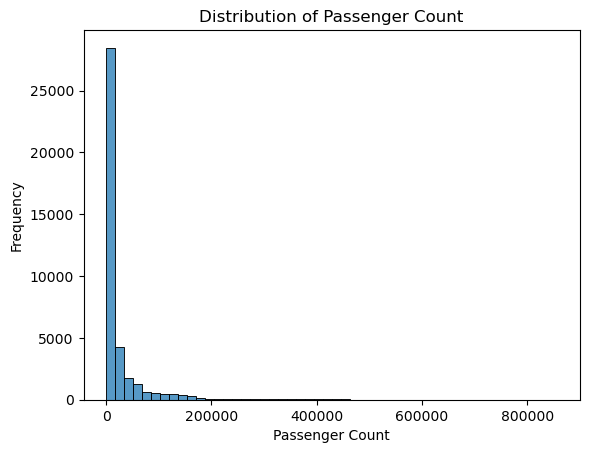

In [7]:
# Original Distribution
sns.histplot(df["passenger_count"], bins=50)
plt.title("Distribution of Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Frequency")
plt.show()

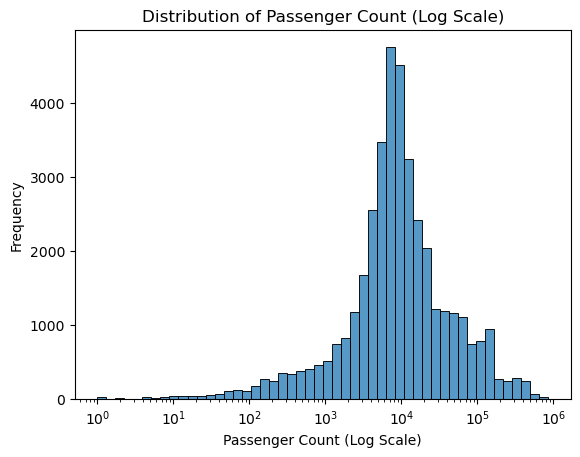

In [8]:
# the original histogram reflects a right skewed distribution with high density at lower counts
# a log scale transformation was applied to better reveal the underlying distribution shape
# the log scale distribution approximates a normal distribution, centered around 10,000 passengers
sns.histplot(df["passenger_count"], bins=50, log_scale=True)
plt.title("Distribution of Passenger Count (Log Scale)")
plt.xlabel("Passenger Count (Log Scale)")
plt.ylabel("Frequency")
plt.show()

### Passenger Trends Over Time

#### By Year

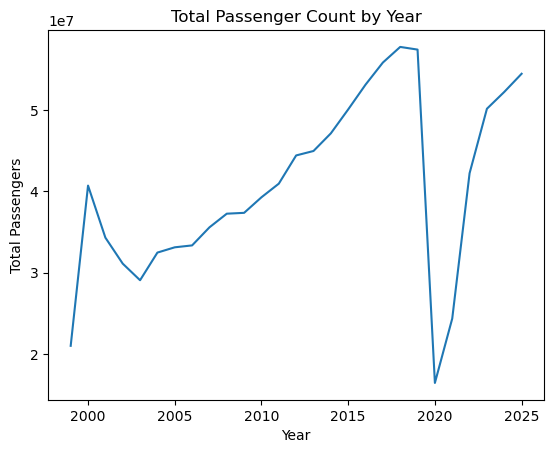

In [9]:
# Totaling passenger count by year
# 2026 shows incomplete data, which takes out the sharp drop
year = df[df["year"] < 2026].groupby("year")["passenger_count"].sum()

year.plot()
plt.title("Total Passenger Count by Year")
plt.xlabel("Year")
plt.ylabel("Total Passengers")
plt.show()

#### By Month

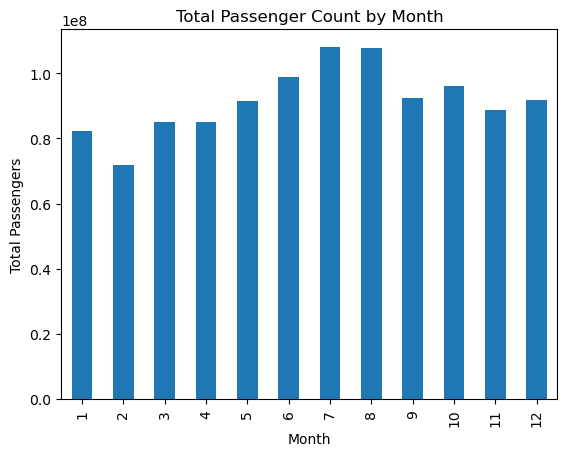

In [10]:
month = df.groupby('month')['passenger_count'].sum()

month.plot(kind='bar')
plt.title("Total Passenger Count by Month")
plt.xlabel("Month")
plt.ylabel("Total Passengers")
plt.show()

### Traffic by Airline

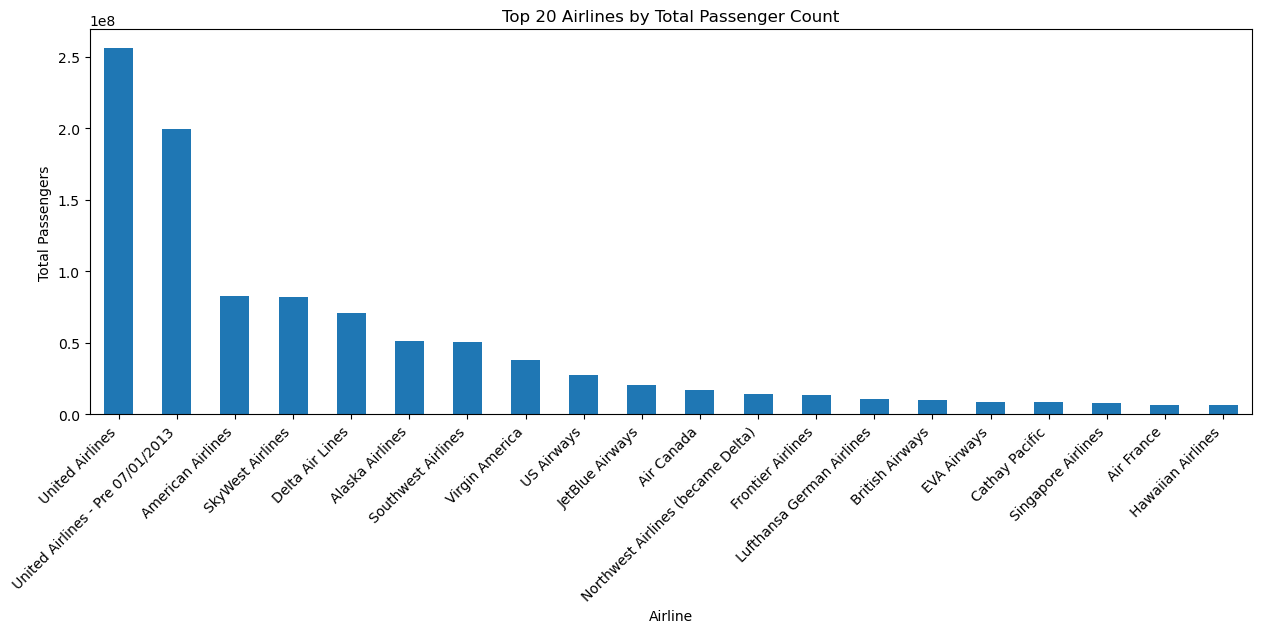

In [11]:
# total passenger count by airline, identifying which airlines dominate SFO traffic
airlines = df.groupby("operating_airline")["passenger_count"].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(15,5))
airlines.plot(kind='bar')
plt.title('Top 20 Airlines by Total Passenger Count')
plt.xlabel('Airline')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Passengers')
plt.show()

### Traffic by Terminal

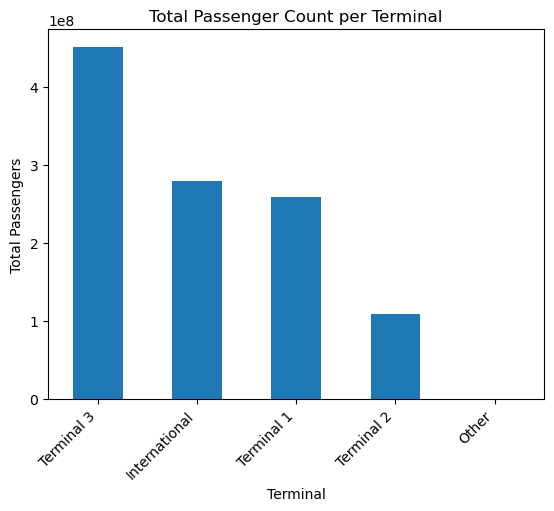

In [12]:
terminal = df.groupby('terminal')['passenger_count'].sum().sort_values(ascending=False)

terminal.plot(kind='bar')
plt.title("Total Passenger Count per Terminal")
plt.xlabel("Terminal")
plt.ylabel("Total Passengers")
plt.xticks(rotation=45, ha='right')
plt.show()

### Traffic by Geographic Region

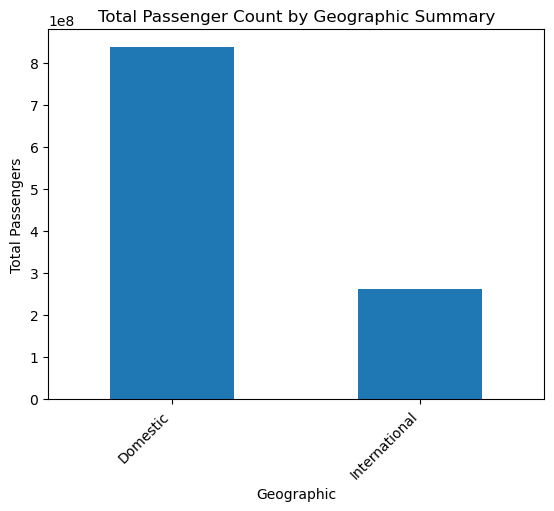

In [13]:
geo = df.groupby('geo_summary')['passenger_count'].sum().sort_values(ascending=False)

geo.plot(kind='bar')
plt.title("Total Passenger Count by Geographic Summary")
plt.xlabel("Geographic")
plt.ylabel("Total Passengers")
plt.xticks(rotation=45, ha='right')
plt.show()

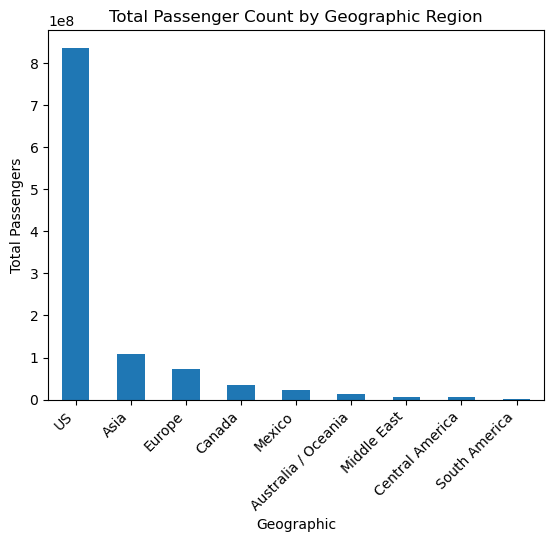

In [14]:
region = df.groupby('geo_region')['passenger_count'].sum().sort_values(ascending=False)

region.plot(kind='bar')
plt.title("Total Passenger Count by Geographic Region")
plt.xlabel("Geographic")
plt.ylabel("Total Passengers")
plt.xticks(rotation=45, ha='right')
plt.show()

### Activity Type Distribution

Activity type was examined and found to be nearly equally distributed between 
enplaned and deplaned passengers, with transit representing only a small portion
of records. This variable seems to have limited predictive value for traffic level 
classification.

In [15]:
print(df["activity_type_code"].value_counts())

activity_type_code
Enplaned          18795
Deplaned          18486
Thru / Transit     2307
Name: count, dtype: int64


# Target Variable Definition

In [33]:
# threshold top 25% - justified by EDA showing right skewed distribution
# top quartile represents meaningfully high traffic at SFO
threshold = df["passenger_count"].quantile(0.75)
df["traffic_level"] = np.where(df["passenger_count"] >= threshold, "High", "Low")

### Stacked and normalized charts

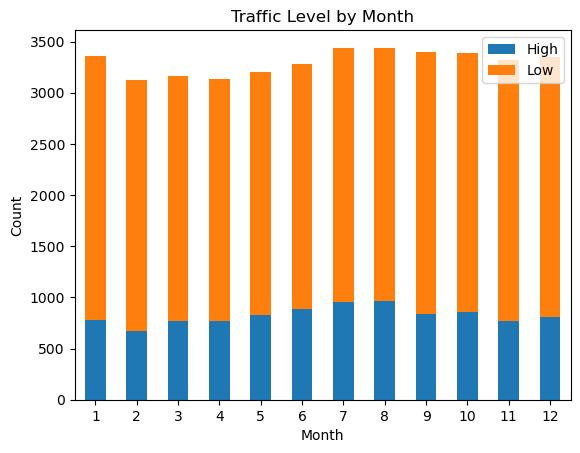

In [36]:
# stacked bar chart of month per low and high traffic levels
crosstab_month = pd.crosstab(df["month"], df["traffic_level"])
crosstab_month.plot(kind='bar', stacked=True)
plt.title("Traffic Level by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.show()

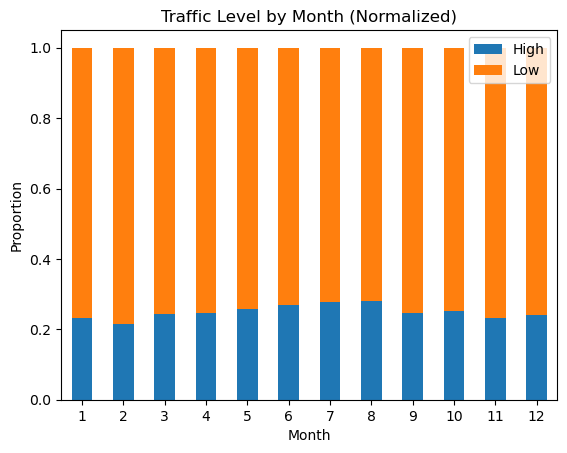

In [37]:
# normalized bar chart, exploring relationship between month and traffic level
crosstab_month = pd.crosstab(df["month"], df["traffic_level"])
crosstab_norm = crosstab_month.div(crosstab_month.sum(axis=1), axis=0)

crosstab_norm.plot(kind='bar', stacked=True)
plt.title("Traffic Level by Month (Normalized)")
plt.xlabel("Month")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.show()

# Train/Test Split

In [17]:
# chronological train/test split, 80% train, 20% test
# training the model on historical data to prevent data leakage
split_date = df["activity_period"].quantile(0.8)

train = df[df["activity_period"] < split_date]
test = df[df["activity_period"] >= split_date]

# define independent variables (features) and dependent variable (target)
X_train = train.drop(["traffic_level", "passenger_count", "activity_period"], axis=1)
y_train = train["traffic_level"]

X_test = test.drop(["traffic_level", "passenger_count", "activity_period"], axis=1)
y_test = test["traffic_level"]

### Split Validation

In [18]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [19]:
df.head()

,activity_period,operating_airline,published_airline,geo_summary,geo_region,activity_type_code,price_category_code,terminal,boarding_area,passenger_count,year,month,traffic_level
0,1999-07-01,ATA Airlines,ATA Airlines,Domestic,US,Deplaned,Low Fare,Terminal 1,B,31432,1999,7,High
101,1999-07-01,TWA,TWA,Domestic,US,Deplaned,Other,Terminal 1,B,37742,1999,7,High
100,1999-07-01,"TACA International Airlines, S.A.","TACA International Airlines, S.A.",International,Central America,Enplaned,Other,Terminal 2,D,4390,1999,7,Low
98,1999-07-01,Swissair,Swissair,International,Europe,Enplaned,Other,Terminal 2,D,4527,1999,7,Low
97,1999-07-01,Swissair,Swissair,International,Europe,Deplaned,Other,Terminal 2,D,4973,1999,7,Low


In [20]:
df["traffic_level"].value_counts()

traffic_level
Low     29690
High     9898
Name: count, dtype: int64

In [21]:
print(X_train.shape, X_test.shape)

(31580, 260) (8008, 260)


In [22]:
print("Train max date:", train["activity_period"].max())
print("Test min date:", test["activity_period"].min())

Train max date: 2021-08-01 00:00:00
Test min date: 2021-09-01 00:00:00


In [23]:
df["activity_period"].unique()[:10]

<DatetimeArray>
['1999-07-01 00:00:00', '1999-08-01 00:00:00', '1999-09-01 00:00:00',
 '1999-10-01 00:00:00', '1999-11-01 00:00:00', '1999-12-01 00:00:00',
 '2000-01-01 00:00:00', '2000-02-01 00:00:00', '2000-03-01 00:00:00',
 '2000-04-01 00:00:00']
Length: 10, dtype: datetime64[us]

# Modeling